# SphericalStreamerCow
Toy model for C/O ratio evolution in protoplanetary disks with stochastic streamer infall.

Set parameters below, then click **▶ Run simulation**.

In [1]:
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import ipywidgets as widgets
from IPython.display import display
from PIL import Image, ImageEnhance


In [2]:
T_MAX    = 2e6   # yr
DT       = 1e3   # yr
T0_RATE  = 1e5   # yr
M_S_MIN  = 1e-9  # M_sun
M_S_MAX  = 0.1   # M_sun
DUR_MIN  = 1e3   # yr
DUR_MAX  = 1e4   # yr
CO_FIXED = 0.4   # fixed initial C/O for disk and streamers


def build_rate(times, decay_fn):
    """Per-step streamer event rate (decreasing with time)."""
    x = times / T_MAX
    if decay_fn == 'linear':
        return np.maximum(0.0, 1.0 - x)
    elif decay_fn == 'quadratic':
        return np.maximum(0.0, (1.0 - x) ** 2)
    else:  # exponential
        r = np.exp(-5.0 * x); r[-1] = 0.0; return r


def build_CO_profile(times, COf, co_fn):
    """Baseline C/O ratio profile (without streamers, increasing with time).

    linear    : steady rise
    quadratic : fast rise early, then levels off  [1-(1-x)^2]
    exponential: even faster early rise, then plateau  [1-exp(-5x)]/[1-exp(-5)]
    """
    x = times / T_MAX           # normalised time 0..1
    if co_fn == 'linear':
        f = x
    elif co_fn == 'quadratic':
        f = 1.0 - (1.0 - x) ** 2
    else:  # exponential
        k = 5.0
        f = (1.0 - np.exp(-k * x)) / (1.0 - np.exp(-k))
    return CO_FIXED + (COf - CO_FIXED) * f


def run_simulation(M0, COf, co_fn, M_res_0, n0, decay_fn, seed):
    CO_s  = CO_FIXED
    rng   = np.random.default_rng(seed)
    times = np.arange(0, T_MAX + DT, DT)
    N     = len(times)

    # Baseline C/O profile (intrinsic disk evolution)
    CO_base = build_CO_profile(times, COf, co_fn)

    # Streamer event probabilities
    rate        = build_rate(times, decay_fn)
    steps_in_T0 = int(T0_RATE / DT)
    exp_in_T0   = rate[:steps_in_T0].sum()
    prob = np.clip(rate * (n0 / exp_in_T0), 0, 1) if exp_in_T0 > 0 else np.zeros(N)

    events = []
    for i, p in enumerate(prob):
        if rng.random() < p:
            mass  = 10 ** rng.uniform(np.log10(M_S_MIN), np.log10(M_S_MAX))
            t_log = (np.log10(mass) - np.log10(M_S_MIN)) / (np.log10(M_S_MAX) - np.log10(M_S_MIN))
            dur_s = max(1, int(round(DUR_MIN * (DUR_MAX / DUR_MIN) ** t_log / DT)))
            events.append((i, dur_s, mass / (dur_s * DT), mass))

    Mdisk  = np.zeros(N);  Mdisk[0]  = M0
    COdisk = np.zeros(N);  COdisk[0] = CO_FIXED
    Mres   = np.zeros(N);  Mres[0]   = M_res_0
    dM_dt  = -M0 / T_MAX

    for i in range(1, N):
        M   = max(0.0, Mdisk[i-1] + dM_dt * DT)
        # Intrinsic C/O step from baseline profile
        CO  = COdisk[i-1] + (CO_base[i] - CO_base[i-1])
        res = Mres[i-1]
        for (i_s, dur_s, dm_yr, _) in events:
            if i_s < i <= i_s + dur_s and res > 0:
                dm  = min(dm_yr * DT, res)
                CO  = (M * CO + dm * CO_s) / (M + dm)
                M  += dm
                res = max(0.0, res - dm)
        Mdisk[i]  = M
        COdisk[i] = CO
        Mres[i]   = res

    event_meta = [(i_s, i_s + dur_s, mass) for (i_s, dur_s, _, mass) in events]
    return times, Mdisk, COdisk, Mres, event_meta


def brightened(img, factor):
    """Apply brightness to an RGBA image (composited on white)."""
    bg = Image.new('RGB', img.size, (255, 255, 255))
    if img.mode == 'RGBA':
        bg.paste(img, mask=img.split()[3])
    else:
        bg.paste(img)
    return np.array(ImageEnhance.Brightness(bg).enhance(factor))


def fmt_mass(m):
    if m >= 0.01:    return f'{m:.3f} M☉'
    elif m > 1e-12:  return f'{m:.2e} M☉'
    else:            return '0 M☉  (depleted)'


_cow = Image.open('lemmling-Cartoon-cow.png').convert('RGBA')
CW, CH = _cow.size
print(f'Cow image loaded: {CW}×{CH} px')


Cow image loaded: 443×500 px


/Users/work/miniforge3/envs/prodimo/lib/python3.13/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


HTML(value='<b>── Disk ──────────────────────────</b>')

FloatSlider(value=0.1, description='M_disk,0 [M☉]', layout=Layout(width='440px'), max=0.5, min=0.01, step=0.01…

FloatSlider(value=1.5, description='C/O disk, final', layout=Layout(width='440px'), max=3.0, min=0.5, step=0.0…

Dropdown(description='C/O evolution', options=(('Linear', 'linear'), ('Quadratic (fast early)', 'quadratic'), …

...

IntSlider(value=5, description='N streamers (100 kyr)', layout=Layout(width='440px'), max=30, style=SliderStyl…

Dropdown(description='Rate decay', index=1, options=(('Linear', 'linear'), ('Quadratic', 'quadratic'), ('Expon…

HTML(value='<b>── Simulation ───────────────────</b>')

IntText(value=42, description='Random seed', layout=Layout(width='290px'), style=DescriptionStyle(description_…

Button(button_style='success', description='▶  Run simulation', layout=Layout(height='36px', width='200px'), s…

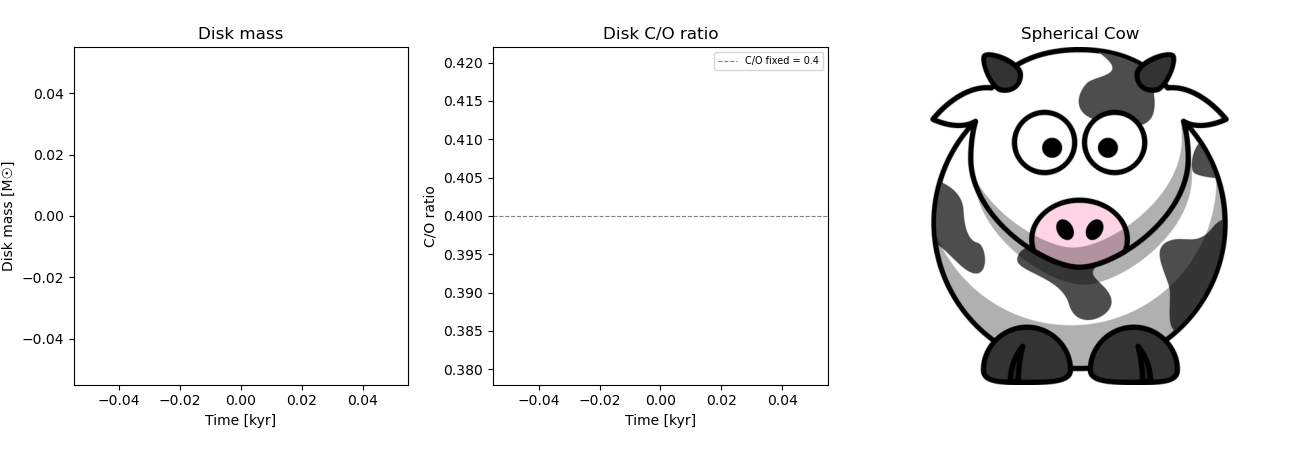

Label(value='Press ▶ Run simulation to start.', layout=Layout(width='380px'))

In [3]:
# ── Parameter widgets ─────────────────────────────────────────────
_W = '440px'
_S = {'description_width': '185px'}
w_M0     = widgets.FloatSlider(value=0.1, min=0.01, max=0.5,  step=0.01,
    description='M_disk,0 [M☉]',         style=_S, layout=widgets.Layout(width=_W))
w_COf    = widgets.FloatSlider(value=1.5, min=0.5,  max=3.0,  step=0.05,
    description='C/O disk, final',        style=_S, layout=widgets.Layout(width=_W))
w_CO_evo = widgets.Dropdown(
    options=[('Linear','linear'),('Quadratic (fast early)','quadratic'),
             ('Exponential (fastest early)','exponential')],
    value='linear', description='C/O evolution', style=_S)
w_Mres   = widgets.FloatSlider(value=0.1, min=0.0,  max=0.5,  step=0.005,
    description='M_reservoir [M☉]',       style=_S, layout=widgets.Layout(width=_W))
w_n0     = widgets.IntSlider(  value=5,   min=0,    max=30,   step=1,
    description='N streamers (100 kyr)',  style=_S, layout=widgets.Layout(width=_W))
w_decay  = widgets.Dropdown(
    options=[('Linear','linear'),('Quadratic','quadratic'),('Exponential','exponential')],
    value='quadratic', description='Rate decay', style=_S)
w_seed   = widgets.IntText(value=42, description='Random seed',
    style=_S, layout=widgets.Layout(width='290px'))
btn      = widgets.Button(description='▶  Run simulation', button_style='success',
    layout=widgets.Layout(width='200px', height='36px'))

# ── Playback controls (created once; range updated on each run) ───
play   = widgets.Play(value=0, min=0, max=1, step=1, interval=22,
                      layout=widgets.Layout(width='80px'))
slider = widgets.IntSlider(value=0, min=0, max=1, step=1, description='',
                           layout=widgets.Layout(width='450px'))
info   = widgets.Label('Press ▶ Run simulation to start.',
                       layout=widgets.Layout(width='380px'))
widgets.jslink((play, 'value'), (slider, 'value'))

# ── Figure — created ONCE, updated in-place on each run ───────────
plt.ioff()
fig, (ax_m, ax_co, ax_cow) = plt.subplots(1, 3, figsize=(13, 4.5))
fig.tight_layout(pad=3.0)

ax_m  .set(xlabel='Time [kyr]', ylabel='Disk mass [M☉]', title='Disk mass')
ax_co .set(xlabel='Time [kyr]', ylabel='C/O ratio',      title='Disk C/O ratio')
ax_cow.set_title('Spherical Cow')
ax_cow.axis('off')
ax_cow.set_xlim(0, CW)
ax_cow.set_ylim(CH, 0)

ref_m,   = ax_m .plot([], [], color='steelblue', alpha=0.15, lw=1)
ref_co,  = ax_co.plot([], [], color='tomato',    alpha=0.15, lw=1)
line_m,  = ax_m .plot([], [], color='steelblue', lw=2)
dot_m,   = ax_m .plot([], [], 'o', color='steelblue', ms=6, zorder=5)
line_co, = ax_co.plot([], [], color='tomato', lw=2)
dot_co,  = ax_co.plot([], [], 'o', color='tomato',    ms=6, zorder=5)
ax_co.axhline(CO_FIXED, color='gray', ls='--', lw=0.8, label=f'C/O fixed = {CO_FIXED}')
ax_co.legend(fontsize=7)
cow_im = ax_cow.imshow(brightened(_cow, 1.0), extent=[0, CW, CH, 0], zorder=0)

# ── Shared simulation state ───────────────────────────────────────
_state          = {}
_active_patches = []


def draw_frame(i):
    if not _state:
        return
    tkyr  = _state['times_kyr']
    Md    = _state['Mdisk']
    COd   = _state['COdisk']
    Mr    = _state['Mres']
    emeta = _state['event_meta']
    evis  = _state['evt_vis']

    line_m .set_data(tkyr[:i+1], Md[:i+1])
    dot_m  .set_data([tkyr[i]], [Md[i]])
    line_co.set_data(tkyr[:i+1], COd[:i+1])
    dot_co .set_data([tkyr[i]], [COd[i]])

    bright = 1.0 - 0.8 * np.clip(
        (COd[i] - CO_FIXED) / max(_state['COf_eff'] - CO_FIXED, 1e-9), 0, 1)
    cow_im.set_data(brightened(_cow, bright))

    for p in _active_patches:
        p.remove()
    _active_patches.clear()
    for k, (i_s, i_e, _) in enumerate(emeta):
        if i_s < i <= i_e:
            cx, cy, r, c = evis[k]
            p = mpatches.Circle((cx, cy), r, color=c, alpha=0.75, zorder=5)
            ax_cow.add_patch(p)
            _active_patches.append(p)
        elif i > i_e:
            cx, cy, r, c = evis[k]
            p = mpatches.Circle((cx, cy), r, color=c, alpha=0.5, zorder=4)
            ax_cow.add_patch(p)
            _active_patches.append(p)

    info.value = f't = {tkyr[i]:.0f} kyr   |   reservoir: {fmt_mass(Mr[i])}'
    fig.canvas.draw_idle()


def on_run(_btn):
    times, Mdisk, COdisk, Mres, event_meta = run_simulation(
        w_M0.value, w_COf.value, w_CO_evo.value, w_Mres.value,
        w_n0.value, w_decay.value, w_seed.value)

    times_kyr = times / 1e3
    N = len(times)

    rng_vis = np.random.default_rng(w_seed.value + 1)
    evt_vis = []
    for (_, _, mass) in event_meta:
        cx     = rng_vis.uniform(0.1 * CW, 0.9 * CW)
        cy     = rng_vis.uniform(0.1 * CH, 0.9 * CH)
        r_norm = (np.log10(mass) - np.log10(M_S_MIN)) / (np.log10(M_S_MAX) - np.log10(M_S_MIN))
        evt_vis.append((cx, cy, 10 + r_norm * 50, rng_vis.random(3).tolist()))

    ref_m .set_data(times_kyr, Mdisk)
    ref_co.set_data(times_kyr, COdisk)
    ax_m .set_xlim(0, times_kyr[-1])
    ax_m .set_ylim(0, Mdisk.max() * 1.15)
    ax_co.set_xlim(0, times_kyr[-1])
    ax_co.set_ylim(COdisk.min() * 0.85, COdisk.max() * 1.1)

    play.max      = N - 1
    slider.max    = N - 1
    play.interval = max(20, int(45_000 / N))
    play.value    = 0
    slider.value  = 0

    _state.update(dict(
        times_kyr=times_kyr, Mdisk=Mdisk, COdisk=COdisk, Mres=Mres,
        event_meta=event_meta, evt_vis=evt_vis, COf_eff=w_COf.value))

    print(f'{len(event_meta)} streamer event(s)  |  '
          f'reservoir at end: {fmt_mass(Mres[-1])}')
    draw_frame(0)


slider.observe(lambda chg: draw_frame(chg['new']), names='value')
btn.on_click(on_run)

# ── Layout ────────────────────────────────────────────────────────
display(
    widgets.HTML('<b>── Disk ──────────────────────────</b>'),
    w_M0, w_COf, w_CO_evo,
    widgets.HTML('<b>── Streamers ────────────────────</b>'),
    w_Mres, w_n0, w_decay,
    widgets.HTML('<b>── Simulation ───────────────────</b>'),
    w_seed, btn,
    fig.canvas,
    widgets.HBox([play, slider]),
    info,
)
plt.ion()
